Distribución de clases:
etiqueta
enfermo    1535
sano        450
Name: count, dtype: int64


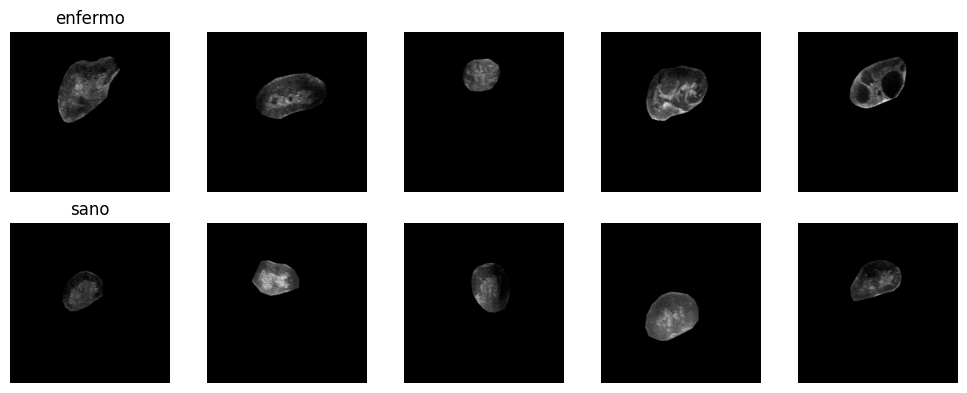

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Directorios
IMAGE_DIR = "images_with_mask"
TXT_DIR = "data/raw/labels"
IMAGE_SIZE = (224, 224)

# Función para extraer la etiqueta (0 o 1) desde un .txt
def extract_label_from_txt(txt_path):
    with open(txt_path, 'r') as f:
        for line in f:
            if line.startswith("Global diagnosis:"):
                return int(line.strip().split(":")[1].strip())
    raise ValueError(f"No se encontró 'Global diagnosis' en {txt_path}")

# Cargar las imágenes y etiquetas
rutas = []
etiquetas = []

for filename in os.listdir(IMAGE_DIR):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        id_imagen = os.path.splitext(filename)[0]  # Ej: "1" de "1.jpg"
        txt_path = os.path.join(TXT_DIR, f"{id_imagen}.txt")
        if os.path.exists(txt_path):
            etiqueta_binaria = extract_label_from_txt(txt_path)
            rutas.append(os.path.join(IMAGE_DIR, filename))
            etiquetas.append("sano" if etiqueta_binaria == 0 else "enfermo")
        else:
            print(f"⚠️ Archivo .txt no encontrado para {filename}")

# Crear DataFrame
df = pd.DataFrame({'ruta': rutas, 'etiqueta': etiquetas})

# Mostrar distribución de clases
print("Distribución de clases:")
print(df['etiqueta'].value_counts())

# Visualizar imágenes de ejemplo
def mostrar_ejemplos(df, n=5):
    clases = df['etiqueta'].unique()
    fig, axes = plt.subplots(len(clases), n, figsize=(n*2, len(clases)*2))
    for i, clase in enumerate(clases):
        ejemplos = df[df['etiqueta'] == clase].sample(n)
        for j, (_, row) in enumerate(ejemplos.iterrows()):
            img = Image.open(row['ruta']).resize(IMAGE_SIZE)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(clase)
    plt.tight_layout()
    plt.show()

mostrar_ejemplos(df)


In [5]:
from sklearn.model_selection import train_test_split

# Separar un 15% como test ciego
df_temp, df_test = train_test_split(df, test_size=0.15, stratify=df['etiqueta'], random_state=SEED)

# Codificar etiquetas como números (necesario para class_weight)
df_temp['label_num'] = df_temp['etiqueta'].map({'sano': 0, 'enfermo': 1})
df_test['label_num'] = df_test['etiqueta'].map({'sano': 0, 'enfermo': 1})


In [6]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Parámetros
NUM_FOLDS = 5
SEED = 42
BATCH_SIZE = 32
IMG_SHAPE = (224, 224)

# Inicializar folds estratificados
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

# Usar solo el primer fold (puedes iterar luego)
for fold_index, (train_idx, val_idx) in enumerate(skf.split(df_temp['ruta'], df_temp['label_num'])):
    print(f"Usando Fold {fold_index+1}/{NUM_FOLDS}")
    df_train = df_temp.iloc[train_idx]
    df_val = df_temp.iloc[val_idx]
    break

# class_weight
weights = compute_class_weight(class_weight='balanced',
                                classes=np.unique(df_train['label_num']),
                                y=df_train['label_num'])
class_weights = dict(enumerate(weights))

# Generadores
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    df_val,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)


Usando Fold 1/5
Found 1349 validated image filenames belonging to 2 classes.
Found 338 validated image filenames belonging to 2 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Cargar base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SHAPE + (3,))
base_model.trainable = False  # congelado inicialmente

# Clasificador
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

# Compilar
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Entrenamiento inicial (solo top)
history_frozen = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# Fine tuning – descongelar parte de la base
base_model.trainable = True
for layer in base_model.layers[:-30]:  # puedes ajustar cuántas descongelas
    layer.trainable = False

# Recompilar con lr más bajo
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Entrenamiento fino
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 271ms/step - accuracy: 0.5526 - loss: 1.3302 - val_accuracy: 0.7722 - val_loss: 0.5459 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.7542 - loss: 0.6570 - val_accuracy: 0.7722 - val_loss: 0.6029 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.7811 - loss: 0.5413 - val_accuracy: 0.7722 - val_loss: 0.6419 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.7969 - loss: 0.5108 - val_accuracy: 0.7722 - val_loss: 0.6625 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.7580 - loss: 0.5684 - val_accuracy: 0.7722 - val_loss: 0.6633 - learning_rate: 2.0000e-05
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step - accuracy: 0.7699 - loss: 0.5503 - val_accuracy: 0.7722 - val_loss: 0.6658 - learning_rate: 2.0000e-05
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - acc

In [11]:
history_finetune.history

{'accuracy': [0.772424042224884,
  0.7739065885543823,
  0.7731652855873108,
  0.7753891944885254,
  0.7761304378509521,
  0.7753891944885254,
  0.7746478915214539,
  0.7746478915214539,
  0.779836893081665,
  0.7761304378509521,
  0.7761304378509521,
  0.7761304378509521,
  0.7813194990158081,
  0.7805781960487366,
  0.779836893081665,
  0.7753891944885254,
  0.7783543467521667,
  0.7842846512794495,
  0.7761304378509521,
  0.7776130437850952],
 'loss': [0.5534001588821411,
  0.5016944408416748,
  0.492914617061615,
  0.48349833488464355,
  0.4732724726200104,
  0.47086307406425476,
  0.46646732091903687,
  0.4518810510635376,
  0.44943711161613464,
  0.44340476393699646,
  0.4346957802772522,
  0.43295684456825256,
  0.4236941933631897,
  0.426190584897995,
  0.42973804473876953,
  0.42681822180747986,
  0.4291229844093323,
  0.42303621768951416,
  0.4246380627155304,
  0.4235251545906067],
 'val_accuracy': [0.7721893787384033,
  0.7721893787384033,
  0.7662721872329712,
  0.76923078

In [12]:
history_frozen.history


{'accuracy': [0.644922137260437,
  0.7664936780929565,
  0.772424042224884,
  0.7731652855873108,
  0.7731652855873108,
  0.7739065885543823],
 'loss': [1.0604408979415894,
  0.6074267625808716,
  0.5516791939735413,
  0.5492763519287109,
  0.5373203158378601,
  0.5400820970535278],
 'val_accuracy': [0.7721893787384033,
  0.7721893787384033,
  0.7721893787384033,
  0.7721893787384033,
  0.7721893787384033,
  0.7721893787384033],
 'val_loss': [0.5458647012710571,
  0.6028600335121155,
  0.6419077515602112,
  0.6625176668167114,
  0.6633161902427673,
  0.6657848954200745],
 'learning_rate': [9.999999747378752e-05,
  9.999999747378752e-05,
  9.999999747378752e-05,
  9.999999747378752e-05,
  1.9999999494757503e-05,
  1.9999999494757503e-05]}

In [15]:
df

,ruta,etiqueta
0,images_with_mask/63.jpg,enfermo
1,images_with_mask/823.jpg,sano
2,images_with_mask/1409.jpg,sano
3,images_with_mask/189.jpg,enfermo
4,images_with_mask/77.jpg,sano
...,...,...
1980,images_with_mask/190.jpg,enfermo
1981,images_with_mask/1404.jpg,enfermo
1982,images_with_mask/1410.jpg,sano
1983,images_with_mask/184.jpg,enfermo


In [16]:
from sklearn.model_selection import train_test_split

# Dividir en 85% train+val (df_temp) y 15% test
df_temp, df_test = train_test_split(
    df,
    test_size=0.15,
    stratify=df['etiqueta'],
    random_state=SEED
)

# Dividir df_temp en 85% train y 15% val (≈ 72.25% train total, 12.75% val)
df_train, df_val = train_test_split(
    df_temp,
    test_size=0.15,
    stratify=df_temp['etiqueta'],
    random_state=SEED
)

# Comprobación
print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))
print("Clases en Train:", df_train['etiqueta'].value_counts(normalize=True))
print("Clases en Val:", df_val['etiqueta'].value_counts(normalize=True))
print("Clases en Test:", df_test['etiqueta'].value_counts(normalize=True))


Train: 1433
Val: 254
Test: 298
Clases en Train: etiqueta
enfermo    0.773901
sano       0.226099
Name: proportion, dtype: float64
Clases en Val: etiqueta
enfermo    0.771654
sano       0.228346
Name: proportion, dtype: float64
Clases en Test: etiqueta
enfermo    0.771812
sano       0.228188
Name: proportion, dtype: float64


In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos de clase
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['etiqueta']),
    y=df_train['etiqueta']
)
class_weights = dict(zip(np.unique(df_train['etiqueta']), weights))

print(class_weights)  # ej. {0: 3.4, 1: 1.0}


{'enfermo': np.float64(0.6460775473399459), 'sano': np.float64(2.2114197530864197)}


In [18]:
history_weighted = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.8032 - loss: 0.4803 - val_accuracy: 0.7219 - val_loss: 0.5144
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 299ms/step - accuracy: 0.7917 - loss: 0.4768 - val_accuracy: 0.7130 - val_loss: 0.5340
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - accuracy: 0.7969 - loss: 0.4313 - val_accuracy: 0.6834 - val_loss: 0.5460
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 300ms/step - accuracy: 0.7840 - loss: 0.4673 - val_accuracy: 0.6746 - val_loss: 0.5566
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 306ms/step - accuracy: 0.7971 - loss: 0.4424 - val_accuracy: 0.6657 - val_loss: 0.5665
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - accuracy: 0.7880 - loss: 0.4461 - val_accuracy: 0.6598 - val_loss: 0.5729


In [20]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Parámetros ---
IMG_SHAPE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# --- Generadores ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# --- Cálculo de class_weight ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['etiqueta']),
    y=df_train['etiqueta']
)

class_weight_dict = dict(enumerate(class_weights))

print("Pesos de clase:", class_weight_dict)


Found 1433 validated image filenames belonging to 2 classes.
Found 254 validated image filenames belonging to 2 classes.
Found 298 validated image filenames belonging to 2 classes.
Pesos de clase: {0: np.float64(0.6460775473399459), 1: np.float64(2.2114197530864197)}


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Descongelar la base para fine-tuning
base_model.trainable = True

# Recompilar con tasa de aprendizaje más baja
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1, min_lr=1e-6)

# Entrenar
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 307ms/step - accuracy: 0.8147 - loss: 0.7739 - val_accuracy: 0.6181 - val_loss: 0.6084 - learning_rate: 1.0000e-05
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 294ms/step - accuracy: 0.7764 - loss: 0.6139 - val_accuracy: 0.5669 - val_loss: 0.6637 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step - accuracy: 0.7390 - loss: 0.5609 - val_accuracy: 0.5906 - val_loss: 0.6245 - learning_rate: 1.0000e-05
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.7197 - loss: 0.5461 - val_accuracy: 0.6181 - val_loss: 0.6072 - learning_rate: 1.0000e-05
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 290ms/step - accuracy: 0.7249 - loss: 0.5265 - val_accuracy: 0.6102 - val_loss: 0.6083 - learning_rate: 1.0000e-05
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 284ms/step - accuracy: 0.7320 - loss: 0.5200 - val_accuracy: 0.6102 - val_loss: 0.6047 - learning_rate: 1.0000e-05
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 279ms/step - acc

Found 298 validated image filenames belonging to 2 classes.


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step

📋 Classification Report:
              precision    recall  f1-score   support

     enfermo       0.91      0.58      0.71       230
        sano       0.36      0.81      0.50        68

    accuracy                           0.63       298
   macro avg       0.64      0.70      0.61       298
weighted avg       0.79      0.63      0.66       298



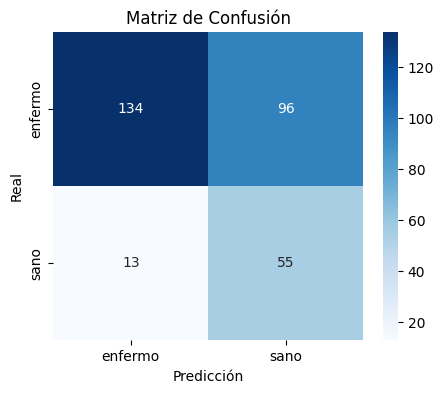

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generador para test
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    df_test,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

# Predicciones
y_pred_proba = model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Reporte
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step


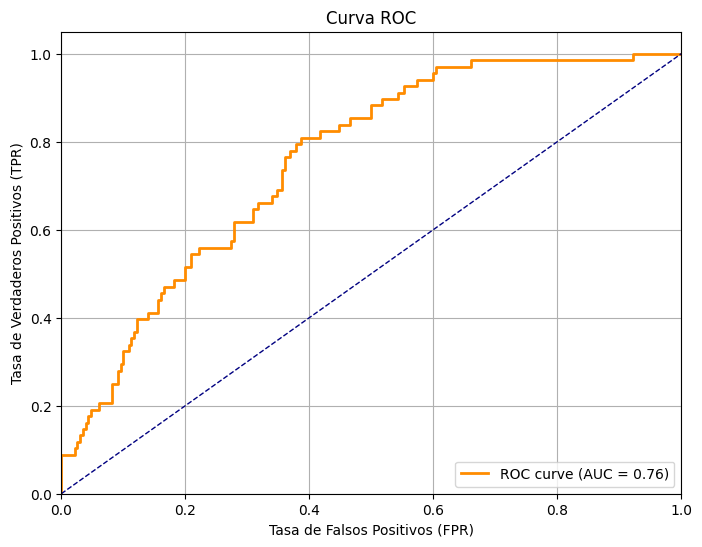

In [24]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Obtener predicciones de probabilidad sobre el conjunto de test
y_probs = model.predict(test_generator)
y_true = test_generator.classes  # etiquetas verdaderas
y_pred_prob = y_probs.ravel()   # asegurar vector plano

# Calcular FPR, TPR y umbral para la curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


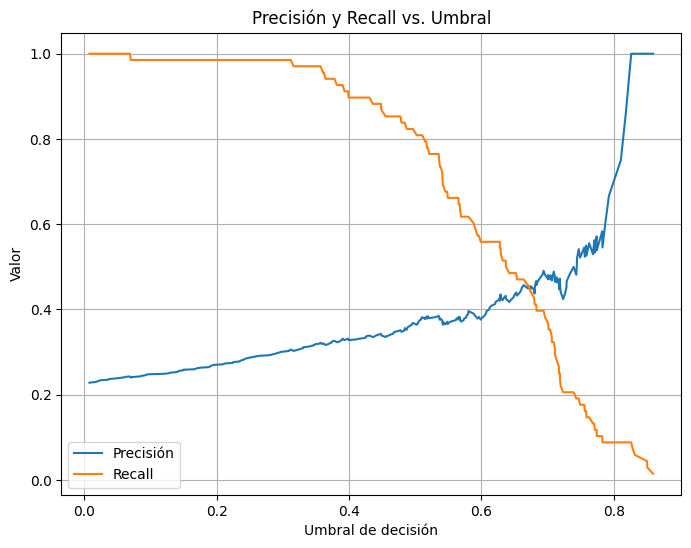

In [25]:
from sklearn.metrics import precision_recall_curve

# Curva precisión-recall
precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precisión')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Umbral de decisión')
plt.ylabel('Valor')
plt.title('Precisión y Recall vs. Umbral')
plt.legend()
plt.grid(True)
plt.show()


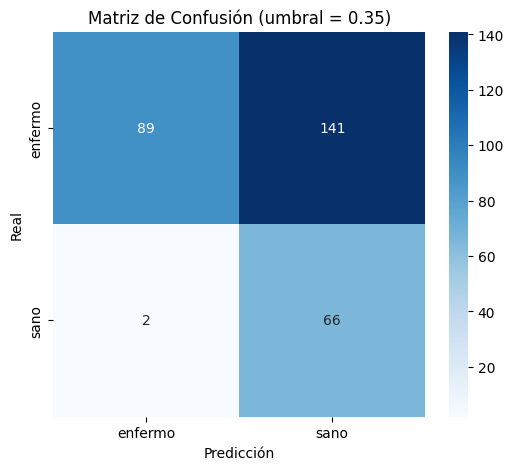

📋 Classification Report (umbral = 0.35 ):
              precision    recall  f1-score   support

     enfermo       0.98      0.39      0.55       230
        sano       0.32      0.97      0.48        68

    accuracy                           0.52       298
   macro avg       0.65      0.68      0.52       298
weighted avg       0.83      0.52      0.54       298



In [26]:
# Aplicamos nuevo umbral
nuevo_umbral = 0.35
y_pred_nuevo = (y_pred_prob >= nuevo_umbral).astype(int)

# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_nuevo)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['enfermo', 'sano'],
            yticklabels=['enfermo', 'sano'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión (umbral = {nuevo_umbral})')
plt.show()

# Classification report
print("📋 Classification Report (umbral =", nuevo_umbral, "):")
print(classification_report(y_true, y_pred_nuevo, target_names=['enfermo', 'sano']))


In [32]:
y_test = df_test['etiqueta'].values

# Mapeo explícito de etiquetas a enteros
etiqueta_map = {'enfermo': 0, 'sano': 1}
y_test = df_test['etiqueta'].map(etiqueta_map).values



Mejor umbral: 0.66 con F1-score macro = 0.6482


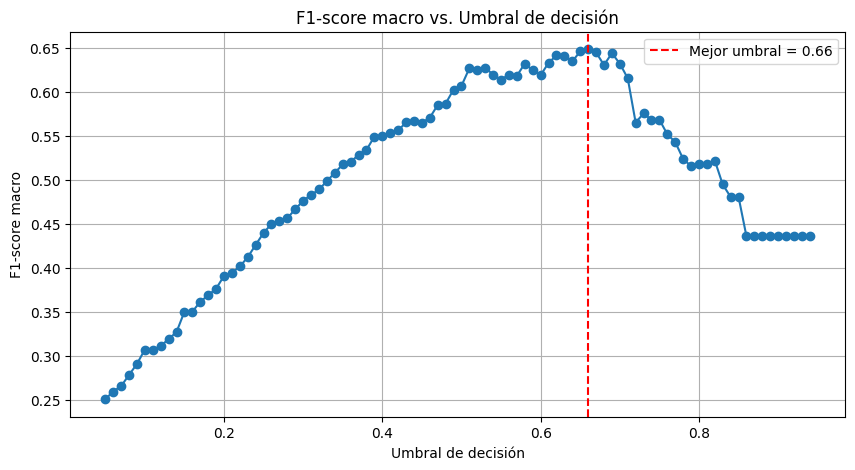

In [33]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Asegúrate de tener estas variables ya definidas:
# y_test: etiquetas verdaderas (0 y 1)
# y_prob: probabilidades predichas por el modelo (output de model.predict)

umbrales = np.arange(0.05, 0.95, 0.01)
f1_macros = []

for umbral in umbrales:
    y_pred_umbral = (y_probs >= umbral).astype(int)
    f1 = f1_score(y_test, y_pred_umbral, average='macro')
    f1_macros.append(f1)

# Encontrar el mejor umbral
mejor_idx = np.argmax(f1_macros)
mejor_umbral = umbrales[mejor_idx]
mejor_f1 = f1_macros[mejor_idx]

# Mostrar resultados
print(f"Mejor umbral: {mejor_umbral:.2f} con F1-score macro = {mejor_f1:.4f}")

# Gráfica
plt.figure(figsize=(10, 5))
plt.plot(umbrales, f1_macros, marker='o')
plt.axvline(mejor_umbral, color='r', linestyle='--', label=f'Mejor umbral = {mejor_umbral:.2f}')
plt.title("F1-score macro vs. Umbral de decisión")
plt.xlabel("Umbral de decisión")
plt.ylabel("F1-score macro")
plt.legend()
plt.grid(True)
plt.show()


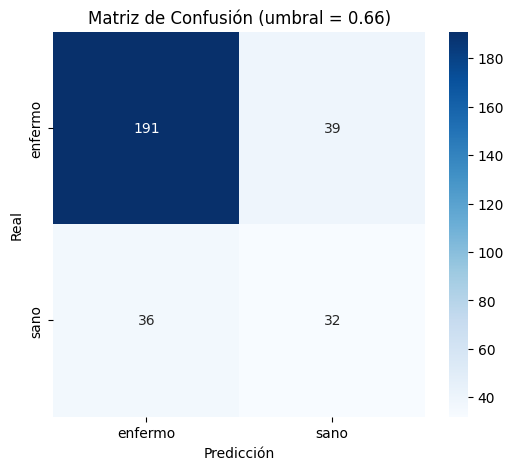

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predicciones con el umbral óptimo
y_pred_opt = (y_probs >= 0.66).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
labels = ['enfermo', 'sano']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (umbral = 0.66)')
plt.show()


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt, target_names=['enfermo', 'sano']))


              precision    recall  f1-score   support

     enfermo       0.84      0.83      0.84       230
        sano       0.45      0.47      0.46        68

    accuracy                           0.75       298
   macro avg       0.65      0.65      0.65       298
weighted avg       0.75      0.75      0.75       298



Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.7504 - loss: 0.5401 - val_accuracy: 0.5630 - val_loss: 0.6756
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 260ms/step - accuracy: 0.7131 - loss: 0.5233 - val_accuracy: 0.5512 - val_loss: 0.6809
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 261ms/step - accuracy: 0.7237 - loss: 0.5246 - val_accuracy: 0.5630 - val_loss: 0.6980
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.7168 - loss: 0.5020 - val_accuracy: 0.5551 - val_loss: 0.7451
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step


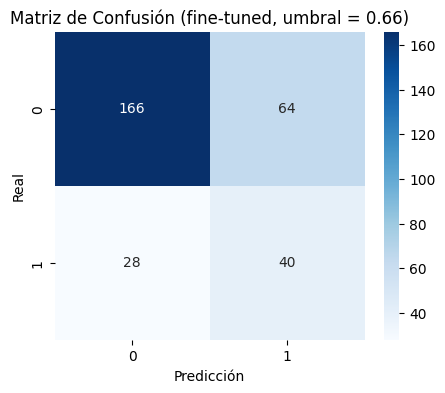

📋 Classification Report (fine-tuned, umbral = 0.66):

              precision    recall  f1-score   support

     enfermo       0.86      0.72      0.78       230
        sano       0.38      0.59      0.47        68

    accuracy                           0.69       298
   macro avg       0.62      0.65      0.62       298
weighted avg       0.75      0.69      0.71       298



In [45]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Paso 1: Descongelar las últimas N capas del modelo base
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Paso 2: Recompilar con una tasa de aprendizaje baja
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Paso 3: Entrenamiento con early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

# Paso 4: Predecir en test
y_probs_finetuned = model.predict(test_generator)

# Paso 5: Umbral óptimo encontrado antes
best_threshold = 0.66
y_pred_finetuned = (y_probs_finetuned > best_threshold).astype(int).flatten()

# Paso 6: Evaluar
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm_finetuned = confusion_matrix(y_test, y_pred_finetuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_finetuned, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión (fine-tuned, umbral = {best_threshold})")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print(f"📋 Classification Report (fine-tuned, umbral = {best_threshold}):\n")
print(classification_report(y_test, y_pred_finetuned, target_names=['enfermo', 'sano']))


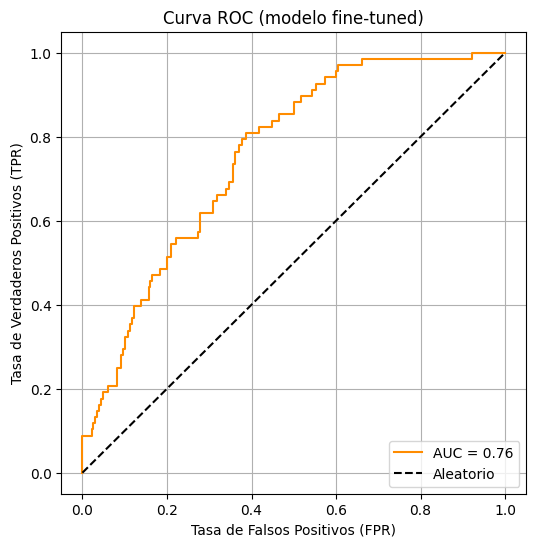

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Asegúrate de que y_test e y_probs están en formato numpy array y tienen la misma longitud
# y_test: array binario (0 y 1), y_probs: probabilidades para la clase positiva (1)

# --- Cálculo de fpr, tpr y AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# --- Gráfico ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (modelo fine-tuned)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
